# Synthetic Options on the MSCI ACWI

**Objective:** price and quote options on the iShares MSCI ACWI ETF in the absence of a liquid options market on the index.

**Methodology:**
1. **Data.** Daily closes from 2018-02-24 to 2024-02-24 for the ACWI ETF and 10 ETFs representing the countries with the largest weights in the index, cached locally by `fetch_data.py` so the notebook runs offline and reproducibly. Returns and volatilities are computed on **adjusted** closes (dividends are not risk); pricing uses **traded** (unadjusted) prices, which are the terms in which the strikes are quoted.
2. **Replicating regression.** OLS of ACWI log returns on the ETFs' log returns, **fitted only up to the valuation date** so the hedge basket never sees the life of the options it hedges. All ten ETFs are individually significant, so every trim is for parsimony, not significance: the intercept (p = 0.31) and the three smallest legs (INDA, EWC, EWT, each under 4% of the basket) are dropped, and EWQ goes as a near-duplicate of EWG (ρ = 0.95), one core-Europe leg is enough for a basket that is only ever traded as a whole, and the fit is unchanged without it (R² = 0.993 vs 0.994 with all ten). The 6-ETF basket defines the **synthetic ACWI**. The model assumptions are validated and a \$1M portfolio in the ACWI is compared against the synthetic one, in sample and out of sample.
3. **Market parameters as of the valuation date (2023-02-24).** A single USD risk-free rate for all the ETFs (they are USD-denominated assets), taken from the 1-year Treasury (FRED DGS1) on that date; each ETF's dividend yield as the average over the preceding sample (total return vs price return, which smooths extraordinary distributions); two volatility estimates computable on that date: historical and EWMA (RiskMetrics, λ=0.94).
4. **Pricing.** Three options are quoted with Black-Scholes with dividends: a 9m call struck at \$85, a 9m digital call struck at \$87 and a 12m call spread struck at \$78/\$100. Each is replicated as a basket of options on the component ETFs, $n_i = w_i \cdot S_{ACWI}/S_i$ units of the option on leg $i$, so every leg contributes its regression weight in *dollar* terms with strikes that preserve the moneyness ($K_i = S_i \cdot K/S_{ACWI}$), tracking the daily mark-to-market. For convex payoffs the basket of options **super-replicates** the option on the basket (imperfect correlations make it worth more); that correlation premium is quantified against the option priced directly on the synthetic index, and the implied volatility embedded in the quote is extracted. Every emitted quote is guarded by explicit no-arbitrage bound assertions, and the two near-strike products (the digital and the spread) are sensitivity-tested against a volatility skew, the dimension flat-vol Black-Scholes ignores and the one that hits them hardest.
5. **Validation.** Stability of the regression weights on a rolling window; a daily delta-hedging backtest (each option is sold at the quoted premium and hedged with the synthetic underlying until expiry, reporting the P&L); and a seeded Monte Carlo in which the six legs are simulated **jointly at their historical correlation**, which puts a confidence band on every backtest number and lets the correlation premium be measured as realized hedging P&L rather than assumed.

## Libraries

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import brentq
from scipy.stats import norm

%matplotlib inline

## Data and log returns

Market data comes from the local cache written by `fetch_data.py` (Yahoo Finance prices, FRED `DGS1` rate), so the notebook runs offline and every number below is reproducible: the same cache always gives the same quotes. Re-run the script to refresh it, or to analyse a different window:

```bash
python fetch_data.py --start 2015-01-01 --end 2021-01-01 --valuation-date 2020-01-02
```

`data` (adjusted closes) for returns, regression and volatilities; `prices` (traded closes) for strikes and pricing.

In [2]:
params = json.loads(open('data/params.json').read())
start_date, end_date = params['start'], params['end']
valuation_date, tickers, r_usd = params['valuation_date'], params['tickers'], params['r_usd']

cached = pd.read_csv('data/prices.csv', header=[0, 1], index_col=0, parse_dates=True)
data = cached['adj_close']  # returns, regression, volatilities: dividend drops are not risk
prices = cached['close']    # strikes and pricing: an option holder receives no dividends

returns = np.log(data / data.shift(1)).dropna()
print(f'{len(returns)} daily returns, {returns.index[0]:%Y-%m-%d} to {returns.index[-1]:%Y-%m-%d}; '
      f'valuation date {valuation_date}')
data.tail()

1508 daily returns, 2018-02-27 to 2024-02-23; valuation date 2023-02-24


Ticker,ACWI,IVV,EWJ,EWU,MCHI,EWC,EWQ,EWG,EWL,INDA,EWT
Date,,,,,,,,,,,
2024-02-16,101.062340,486.301392,62.863762,29.763834,36.828735,35.141842,36.039490,27.778185,44.092209,50.832245,42.675423
2024-02-20,100.774094,483.598358,63.142628,29.927769,36.524914,35.007717,36.399055,27.844076,44.611832,51.189659,42.990234
2024-02-21,100.802925,484.034332,63.012497,29.736511,37.293957,34.959808,36.611103,27.966448,44.715759,50.812389,42.582832
2024-02-22,102.541901,494.148834,64.044273,29.955093,37.759190,35.295132,37.044430,28.427691,44.517357,51.358437,43.221714
2024-02-23,102.580322,494.429810,64.146515,30.064384,37.882614,35.438847,37.191944,28.446516,44.772442,51.427933,42.971718


## Linear regression

The regression window **stops at the valuation date**. The weights define a hedge a desk puts on that day, so they must not be estimated on the option's own life; fitting through the end of the sample would let the replication basket be tuned on the very path the backtest below then grades it against.

In [3]:
# the fit stops at the valuation date: the basket is a hedge chosen on that day and
# must not be estimated on the life of the options it will hedge
fit = returns.loc[:valuation_date]
y = fit['ACWI']
X = sm.add_constant(fit[tickers])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ACWI   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 2.262e+04
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:00:38   Log-Likelihood:                 6966.9
No. Observations:                1258   AIC:                        -1.391e+04
Df Residuals:                    1247   BIC:                        -1.386e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.733e-05   2.71e-05     -1.010      0.3

Only the intercept fails the significance test (p = 0.31); every ETF is individually significant (smallest |t| ≈ 5.3), so significance gives no reason to trim the basket. For parsimony, each name kept is one more leg to trade in every option quote and hedge below. The intercept and the three smallest coefficients in the table above (INDA, EWC, EWT, each under 4% of the basket) are dropped. The surviving legs are then screened for redundancy with variance inflation factors:

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X.drop(columns=['INDA', 'EWC', 'EWT', 'const'])
pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
          index=X.columns, name='VIF').round(1)

IVV      4.3
EWJ      3.3
EWU      6.2
MCHI     1.6
EWQ     14.6
EWG     11.4
EWL      4.7
Name: VIF, dtype: float64

EWQ and EWG are near-duplicates (ρ = 0.95, see the correlation matrix further down): they carry the same core-Europe factor, which is what their VIFs of ≈ 15 and ≈ 11 are signalling. For a basket that is only ever traded and hedged as a whole, the inflated *individual* standard errors behind a high VIF are not themselves a problem, the reason to drop a leg is parsimony: two near-identical legs mean one more option to price and one more hedge to run in every quote, for no additional information. EWQ goes (dropping either leaves R² at 0.993) and the 6-ETF model is re-estimated with heteroskedasticity-robust (HC3) errors:

In [5]:
X = X.drop(columns=['EWQ'])
final_model = sm.OLS(y, X).fit(cov_type='HC3')
print(final_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   ACWI   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                              7865.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):                        0.00
Time:                        17:00:38   Log-Likelihood:                          6816.7
No. Observations:                1258   AIC:                                 -1.362e+04
Df Residuals:                    1252   BIC:                                 -1.359e+04
Df Model:                           6                                                  
Covariance Type:                  HC3                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

### Why the ETF and not the index as the target?

The MSCI ACWI index (`data/IndexMSCI.csv`) is computed from each regional market's close, while every ETF in the basket closes at the same time on NYSE. That timing mismatch misaligns the daily returns and hurts the regression R² without the basket replicating any worse. The replication target is therefore the ACWI ETF: it shares the basket's closing time and is also the underlying in whose terms the strikes are quoted.

In [6]:
msci_index = pd.read_csv('data/IndexMSCI.csv', encoding='utf-8-sig', parse_dates=['Date'], index_col='Date')
r_index = np.log(msci_index / msci_index.shift(1)).dropna()['MSCI ACWI Index']
common = fit.index.intersection(r_index.index)   # same pre-valuation window as the final model
index_model = sm.OLS(r_index.loc[common], fit.loc[common, X.columns]).fit()

print(f'R² replicating the MSCI index (regional closes): {index_model.rsquared:.3f}')
print(f'R² replicating the ACWI ETF (NYSE close):        {final_model.rsquared:.3f}')

R² replicating the MSCI index (regional closes): 0.946
R² replicating the ACWI ETF (NYSE close):        0.993


### Coefficient stability

The regression is re-estimated on a 2-year rolling window (504 trading days), over the **full** sample: this is a diagnostic, not an estimate that feeds any quote, and the segment right of the valuation date is exactly what the fit above is not allowed to use. The weights move gradually and with no regime breaks, which is what makes static weights over the option horizon defensible, and the size of the drift is also why the fit has to stop at the valuation date.

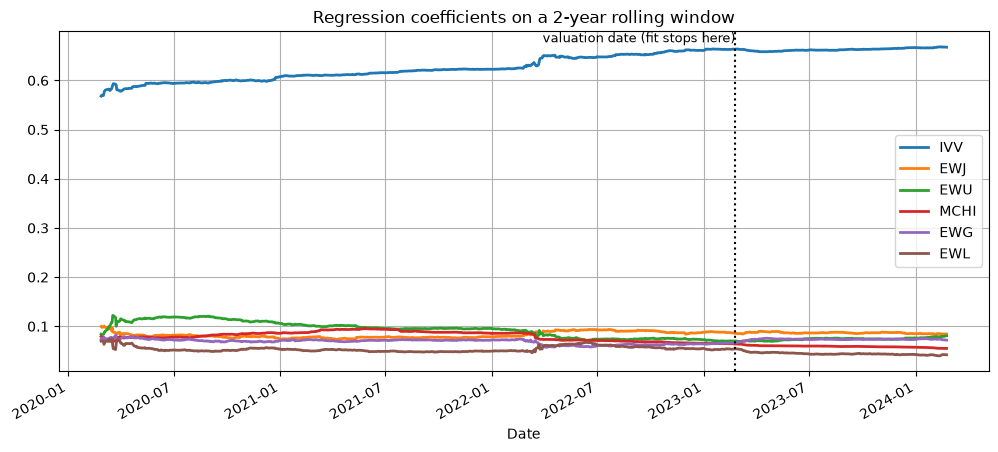

,IVV,EWJ,EWU,MCHI,EWG,EWL
Date,,,,,,
2020-02-27,0.568,0.100,0.084,0.079,0.074,0.070
2023-02-24,0.664,0.086,0.070,0.064,0.067,0.054
2024-02-23,0.667,0.084,0.081,0.055,0.072,0.042


In [7]:
from statsmodels.regression.rolling import RollingOLS

betas = RollingOLS(returns['ACWI'], returns[X.columns], window=504).fit().params.dropna()
ax = betas.plot(figsize=(12, 5), linewidth=2, title='Regression coefficients on a 2-year rolling window')
ax.axvline(pd.Timestamp(valuation_date), color='black', linestyle=':', linewidth=1.5)
ax.annotate('valuation date (fit stops here)', (pd.Timestamp(valuation_date), ax.get_ylim()[1]),
            ha='right', va='top', fontsize=9)
plt.grid(True)
plt.show()
betas.loc[[betas.index[0], betas.index[betas.index <= valuation_date][-1], betas.index[-1]]].round(3)

## Residual analysis

No VIF exceeds the ≈ 10 bar after the screen; the surviving European legs still co-move, which widens their individual confidence intervals but not the joint fit. The basket is only ever traded as a whole, never interpreted coefficient by coefficient.

In [8]:
# Multicollinearity
pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
          index=X.columns, name='VIF').round(2)

IVV     4.31
EWJ     3.28
EWU     5.29
MCHI    1.58
EWG     6.16
EWL     4.56
Name: VIF, dtype: float64

In [9]:
# Residual normality
from scipy.stats import shapiro

stat, p_value = shapiro(final_model.resid)
print(f'Shapiro-Wilk Test statistic: {stat}, p-value: {p_value}')

Shapiro-Wilk Test statistic: 0.9358790355076119, p-value: 7.583061679671644e-23


**Normality: rejected** (W = 0.94, p ≈ 10⁻²³), as for virtually any daily equity return series, the residuals inherit the fat tails visible in the QQ plot below. This threatens neither the weights nor their z-tests: OLS point estimates do not need normal errors, and with n = 1258 the central limit theorem keeps the HC3 inference valid. Only exact small-sample confidence intervals would suffer.

In [10]:
# Zero mean of residuals
from scipy.stats import ttest_1samp

t_test_result = ttest_1samp(final_model.resid, 0)
print(f't-statistic: {t_test_result.statistic}, p-value: {t_test_result.pvalue}')

t-statistic: -0.22282302575149923, p-value: 0.823709447758659


**Zero mean: not rejected** (t ≈ −0.22, p ≈ 0.82). Not automatic in a model without an intercept, nothing forces the residuals to center, so this is real evidence that the basket carries no systematic daily drift against the ACWI over the fitting window.

In [11]:
# Residual autocorrelation
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(final_model.resid)
print(f'Durbin-Watson statistic: {dw_stat}')

Durbin-Watson statistic: 2.5407182418438534


**Autocorrelation: mild and negative** (DW ≈ 2.54; 2 means none, so ρ₁ ≈ −0.27). The typical signature of daily closes bouncing around fair value (closing-auction and bid–ask noise that partly reverses the next day). It does not bias the weights, and for hedging it is benign: consecutive replication errors tend to offset rather than accumulate.

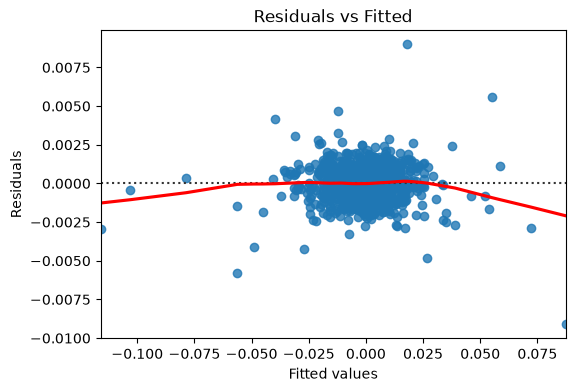

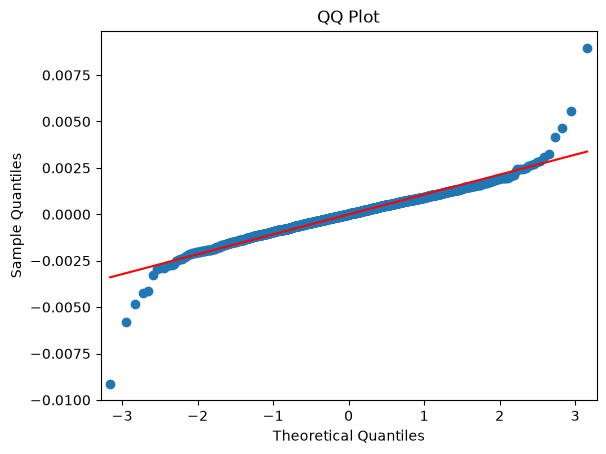

In [12]:
# Residuals vs Fitted
plt.figure(figsize=(6, 4))
sns.residplot(x=final_model.fittedvalues, y=final_model.resid, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# QQ Plot
sm.qqplot(final_model.resid, line='s')
plt.title('QQ Plot')
plt.show()

**Residuals vs fitted:** the lowess line stays flat at zero across the whole range, no missed curvature, so the linear specification is adequate.

**QQ plot:** both tails leave the line, the same fat tails Shapiro–Wilk flags, extreme joint moves are larger than a Gaussian would produce, while the center is well behaved.

## Correlation matrix

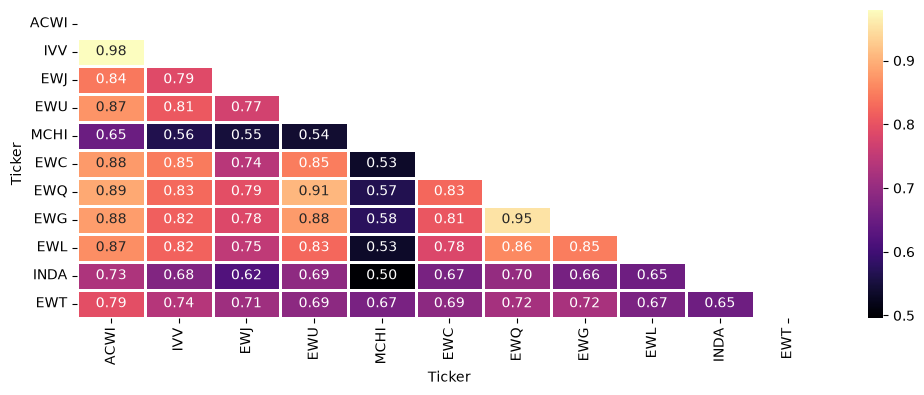

Ticker
ACWI    1.000000
IVV     0.979946
EWJ     0.842343
EWU     0.870902
MCHI    0.650300
EWC     0.877090
EWQ     0.891780
EWG     0.881208
EWL     0.865901
INDA    0.727581
EWT     0.794837
Name: ACWI, dtype: float64


In [13]:
corr = returns.loc[:valuation_date].corr()   # pre-valuation, like every other estimate
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(corr, annot=True, cmap='magma', fmt='.2f', linewidths=1, mask=np.triu(corr))
plt.xticks(rotation=90)
plt.setp(plt.gca().get_xticklabels(), ha='center')
plt.show()
print(corr['ACWI'])

## \$1,000,000 portfolio, in sample and out of sample

The weights are fitted only up to the valuation date, so everything to the right of it is a genuine out-of-sample test of the replication, over exactly the window the options live in.

In [14]:
components = list(X.columns)
weights = final_model.params / final_model.params.sum()
print(weights.round(4))

# the log-return replica of the regression (the tradeable price basket is built at the valuation date)
returns['ACWI_synthetic'] = returns[components].dot(weights)

portfolio = 1_000_000 * np.exp(returns[['ACWI', 'ACWI_synthetic']].cumsum())
gap = portfolio['ACWI_synthetic'] - portfolio['ACWI']
oos = returns.loc[valuation_date:]
te_oos = (oos['ACWI_synthetic'] - oos['ACWI']).std() * np.sqrt(252)
print(f'\nin sample     (to {valuation_date}): synthetic ends {gap.loc[:valuation_date].iloc[-1]:+,.0f} vs ACWI')
print(f'out of sample (after):      synthetic drifts a further '
      f'{gap.iloc[-1] - gap.loc[:valuation_date].iloc[-1]:+,.0f}, '
      f'{te_oos:.2%} annualized tracking error')
portfolio.tail(5).map('${:,.2f}'.format)

IVV     0.6307
EWJ     0.0883
EWU     0.0870
MCHI    0.0686
EWG     0.0720
EWL     0.0533
dtype: float64

in sample     (to 2023-02-24): synthetic ends +11,624 vs ACWI
out of sample (after):      synthetic drifts a further -17,410, 1.17% annualized tracking error


Ticker,ACWI,ACWI_synthetic
Date,,
2024-02-16,"$1,579,129.27","$1,569,235.25"
2024-02-20,"$1,574,625.34","$1,565,443.50"
2024-02-21,"$1,575,075.84","$1,568,102.29"
2024-02-22,"$1,602,247.85","$1,594,840.18"
2024-02-23,"$1,602,848.20","$1,597,062.43"


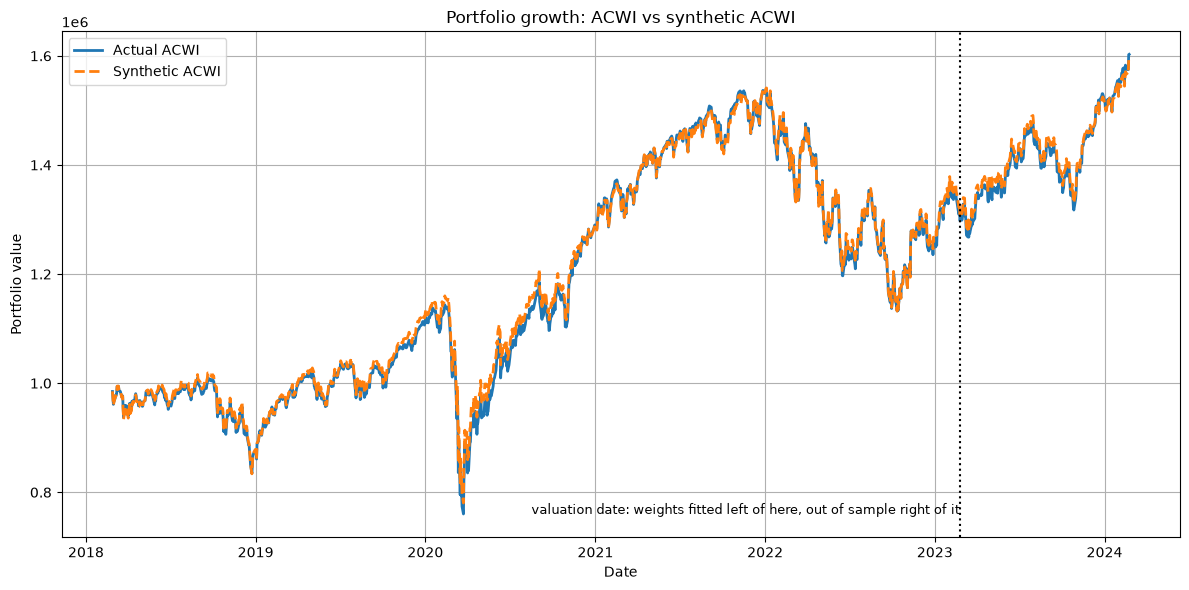

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio.index, portfolio['ACWI'], label='Actual ACWI', linewidth=2)
plt.plot(portfolio.index, portfolio['ACWI_synthetic'], label='Synthetic ACWI', linewidth=2, linestyle='--')
plt.axvline(pd.Timestamp(valuation_date), color='black', linestyle=':', linewidth=1.5)
plt.annotate('valuation date: weights fitted left of here, out of sample right of it',
             (pd.Timestamp(valuation_date), portfolio.min().min()), ha='right', fontsize=9)
plt.title('Portfolio growth: ACWI vs synthetic ACWI')
plt.xlabel('Date')
plt.ylabel('Portfolio value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Market parameters as of the valuation date

Everything is estimated with information available on the valuation date only, the regression weights above included:
- **Risk-free rate:** the ETFs are USD assets listed on NYSE, so everything is discounted with a single USD rate: the 1-year Treasury (FRED, series DGS1) at the valuation-date close, cached by `fetch_data.py`, a maturity in line with the 9- and 12-month expiries.
- **Dividend yield** of each ETF: average over the sample preceding the valuation date, estimated as the log difference between total return (adjusted prices) and price return. Averaging smooths extraordinary, non-recurring distributions that would distort a short trailing estimate (e.g. EWT, in the 10-ETF universe, paid a Dec-2022 special distribution that alone would push its 12-month yield to ~17%).
- **Volatility:** historical and EWMA (RiskMetrics, λ=0.94), which weights the recent past more heavily; both annualized, both on returns up to the valuation date.

In [16]:
print(f'USD risk-free rate (1-year Treasury, FRED DGS1, as of {valuation_date}): {r_usd:.2%}')

T_sample = (pd.Timestamp(valuation_date) - data.index[0]).days / 365
total_return = data.loc[valuation_date, components] / data.iloc[0][components]
price_return = prices.loc[valuation_date, components] / prices.iloc[0][components]
div = np.log(total_return / price_return) / T_sample

prior_returns = returns.loc[:valuation_date]
vol_hist = prior_returns.std() * np.sqrt(252)
# RiskMetrics recursion sigma2_t = L*sigma2_{t-1} + (1-L)*r2_t with L = 0.94: adjust=False is that recursion
vol_ewma = np.sqrt((prior_returns**2).ewm(alpha=0.06, adjust=False).mean().iloc[-1] * 252)

pd.DataFrame({'historical vol': vol_hist[components + ['ACWI_synthetic']],
              'EWMA vol': vol_ewma[components + ['ACWI_synthetic']],
              'dividend yield': div}).map(lambda v: '-' if pd.isna(v) else f'{v:.2%}')

USD risk-free rate (1-year Treasury, FRED DGS1, as of 2023-02-24): 5.05%


,historical vol,EWMA vol,dividend yield
Ticker,,,
ACWI_synthetic,20.38%,14.59%,-
EWG,24.68%,18.75%,2.58%
EWJ,18.06%,14.74%,1.61%
EWL,18.77%,14.27%,2.00%
EWU,22.10%,11.87%,3.82%
IVV,21.88%,16.60%,1.80%
MCHI,29.97%,28.11%,1.42%


## Replication units and adjusted strikes

The strikes (\$85, \$87, \$78, \$100) are in ACWI-ETF terms; each component keeps the same moneyness: $K_i = S_i \cdot K / S_{ACWI}$, using traded prices.

The regression coefficients are **log-return exposures**, so the tradeable replica must hold a dollar fraction $w_i$ of each leg: $n_i = w_i \cdot S_{ACWI} / S_i$ shares of leg $i$, worth exactly $S_{ACWI}$ on the valuation date. Holding $w_i$ *shares* instead would weight the basket by price level, IVV trades near \$400 against \$25–60 for the rest, which makes such a basket 94% IVV by value: a tracker of the S&P 500, not of the ACWI. The cell below quantifies the difference over the 12-month option horizon; option quotes aggregate with the same units $n_i$ (the digital's fixed \$1 payoff aggregates with the weights themselves).

In [17]:
S_A = prices.loc[valuation_date, 'ACWI']
S0 = prices.loc[valuation_date, components]

def expiry(T):
    """Calendar date T years after the valuation date, so the horizons follow the configured window."""
    return pd.Timestamp(valuation_date) + pd.Timedelta(days=round(T * 365))

# n_i = w_i*S_A/S_i shares of leg i: dollar weight w_i, basket worth exactly S_A on the valuation date
units = weights * S_A / S0
prices['ACWI_synthetic'] = prices[components].mul(units).sum(axis=1)

# what holding w_i *shares* would have done over the option horizon: an S&P tracker, not an ACWI one
acwi = prices.loc[valuation_date:expiry(1.0), 'ACWI']
dollar_w = prices.loc[valuation_date:expiry(1.0), 'ACWI_synthetic']
share_w = prices.loc[valuation_date:expiry(1.0), components].dot(weights)
share_w = share_w * S_A / share_w.iloc[0]
def te(b):
    return (np.log(b / b.shift(1)) - np.log(acwi / acwi.shift(1))).std() * np.sqrt(252)
print(f'ACWI on {valuation_date}: ${S_A:.2f}')
print(f'dollar-weighted basket (n_i shares): tracking error {te(dollar_w):.2%}, ends {dollar_w.iloc[-1] - acwi.iloc[-1]:+.2f} vs ACWI')
print(f'share-weighted basket (w_i shares):  tracking error {te(share_w):.2%}, ends {share_w.iloc[-1] - acwi.iloc[-1]:+.2f} vs ACWI')

cols = components + ['ACWI_synthetic']
strikes = pd.DataFrame({K: prices.loc[valuation_date, cols] * (K / S_A) for K in [85, 87, 78, 100]})

# The synthetic index viewed as a single asset: used by the option-on-the-basket comparison, by the
# hedge deltas in the backtest and by the Monte Carlo, so it is defined once, here.
S_syn = prices.loc[valuation_date, 'ACWI_synthetic']   # = S_A by construction
q_syn = (weights * div[components]).sum()              # dollar weights are the w_i themselves
v_syn = vol_hist['ACWI_synthetic']
K85s, K87s, K78s, K100s = strikes.loc['ACWI_synthetic', [85, 87, 78, 100]]
strikes.round(2)

ACWI on 2023-02-24: $88.16
dollar-weighted basket (n_i shares): tracking error 1.17%, ends -0.73 vs ACWI
share-weighted basket (w_i shares):  tracking error 3.04%, ends +5.19 vs ACWI


,85,87,78,100
Ticker,,,,
IVV,383.84,392.87,352.23,451.58
EWJ,53.63,54.89,49.21,63.09
EWU,31.09,31.83,28.53,36.58
MCHI,46.05,47.13,42.26,54.17
EWG,26.07,26.68,23.92,30.67
EWL,42.16,43.15,38.69,49.60
ACWI_synthetic,85.00,87.00,78.00,100.00


## Black-Scholes with dividends

Call: $C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$, $\Delta = e^{-qT} N(d_1)$.

Digital call (cash-or-nothing paying \$1): $C = e^{-rT} N(d_2)$, $\Delta = e^{-rT}\,\varphi(d_2)/(S\sigma\sqrt{T})$.

Call spread: $C = C(K_1) - C(K_2)$, $\Delta = \Delta(K_1) - \Delta(K_2)$.

Put (used only to assert put–call parity in the self-checks): $P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$.

With $d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}$, $d_2 = d_1 - \sigma\sqrt{T}$.

In [18]:
def bs_d1_d2(S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)

def call(S, K, T, r, q, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def call_delta(S, K, T, r, q, sigma):
    return np.exp(-q * T) * norm.cdf(bs_d1_d2(S, K, T, r, q, sigma)[0])

def put(S, K, T, r, q, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def digital(S, K, T, r, q, sigma):
    return np.exp(-r * T) * norm.cdf(bs_d1_d2(S, K, T, r, q, sigma)[1])

def digital_delta(S, K, T, r, q, sigma):
    d2 = bs_d1_d2(S, K, T, r, q, sigma)[1]
    return np.exp(-r * T) * norm.pdf(d2) / (S * sigma * np.sqrt(T))

def price_series(fn, K, T_init, sigma, until, agg):
    """Daily series of fn for each component and the synthetic, from the valuation date to `until`.
    agg maps the component columns into the synthetic one: the replication units n_i for
    proportional payoffs (call, spread) and the weights w_i for the digital's fixed $1 payoff:
    both exact on every date. The *delta* aggregations (w_i for call deltas, w_i·S_i/S_A for the
    digital's) are exact only **at the valuation date**; away from it the legs drift apart and the
    correct weight becomes n_i·S_i(t)/S_basket(t). Deltas are therefore always requested with
    until=valuation_date, so a misaggregated delta is never produced in the first place.
    Per-component columns stay in their own terms."""
    S = prices.loc[valuation_date:until, components]
    T = T_init - (S.index - S.index[0]).days / 365
    S, T = S[T > 0], T[T > 0]
    out = pd.DataFrame(fn(S.values, strikes.loc[components, K].values, np.asarray(T)[:, None],
                          r_usd, div[components].values, sigma[components].values),
                       index=S.index, columns=components)
    out['ACWI_synthetic'] = out[components].dot(agg)
    return out

# minimal self-checks
assert abs(call(100, 80, 1, 0.0, 0.0, 1e-9) - 20) < 1e-4               # no vol, rate or dividend: intrinsic value
assert call(100, 100, 1, 0.03, 0.02, 0.2) < call(100, 100, 1, 0.03, 0.0, 0.2)  # dividends make the call cheaper
assert abs(digital(100, 80, 1, 0.0, 0.0, 1e-9) - 1) < 1e-6             # deep-ITM digital pays ~1
assert 0 < digital(100, 100, 1, 0.02, 0.0, 0.2) < np.exp(-0.02)
# put-call parity, C - P = S·e^(-qT) - K·e^(-rT): the identity a mispriced pair would break
for S_, K_, sig_ in [(100.0, 80.0, 0.15), (88.0, 87.0, 0.2), (100.0, 120.0, 0.35)]:
    assert abs(call(S_, K_, 0.75, 0.05, 0.02, sig_) - put(S_, K_, 0.75, 0.05, 0.02, sig_)
               - (S_ * np.exp(-0.02 * 0.75) - K_ * np.exp(-0.05 * 0.75))) < 1e-12

## 9-month call, strike \$85

Two deltas are reported and they are **not the same number**. `basket Δ` is the delta of what is actually sold, the basket of options, aggregated as Σ wᵢΔᵢ. `on-basket Δ` treats the synthetic index as one asset with its own volatility `v_syn`, and is the delta the hedging backtest and the Monte Carlo below actually trade. The gap is small here but it is not noise: it is the same basket-vs-option-on-basket distinction that produces the correlation premium further down.

In [19]:
call85_hist = price_series(call, 85, 0.75, vol_hist, expiry(0.75), units)
call85_ewma = price_series(call, 85, 0.75, vol_ewma, expiry(0.75), units)
delta85_hist = price_series(call_delta, 85, 0.75, vol_hist, valuation_date, weights)

summary = pd.DataFrame({'price (hist vol)': call85_hist.iloc[0].round(2),
                        'price (EWMA vol)': call85_ewma.iloc[0].round(2),
                        'basket delta % (hist vol)': (delta85_hist.iloc[0] * 100).round(2)})
# the delta the backtest and the MC actually hedge with: synthetic index as one asset at its own vol
summary.loc['ACWI_synthetic', 'on-basket delta % (hedged)'] = \
    call_delta(S_syn, K85s, 0.75, r_usd, q_syn, v_syn) * 100
print(f'As of {valuation_date}:')
summary.round(2).astype(object).fillna('')

As of 2023-02-24:


,price (hist vol),price (EWMA vol),basket delta % (hist vol),on-basket delta % (hedged)
IVV,41.83,35.36,65.23,
EWJ,5.24,4.69,67.49,
EWU,3.1,2.08,61.32,
MCHI,6.33,6.05,63.94,
EWG,2.98,2.47,62.98,
EWL,4.13,3.54,66.24,
ACWI_synthetic,9.26,7.82,64.9,65.45


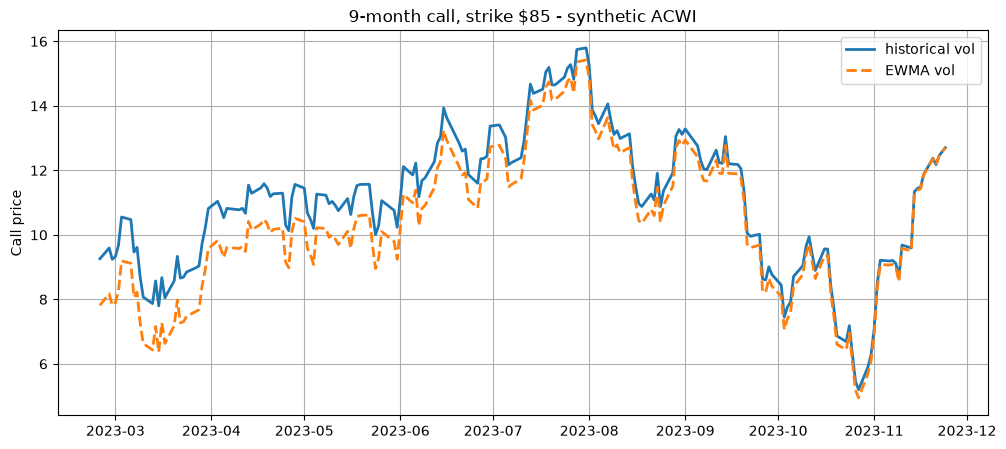

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(call85_hist.index, call85_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(call85_ewma.index, call85_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('9-month call, strike $85 - synthetic ACWI')
plt.ylabel('Call price')
plt.legend()
plt.grid(True)
plt.show()

## 9-month digital call, strike \$87

In [21]:
digital87_hist = price_series(digital, 87, 0.75, vol_hist, expiry(0.75), weights)
digital87_ewma = price_series(digital, 87, 0.75, vol_ewma, expiry(0.75), weights)
deltadigital87_hist = price_series(digital_delta, 87, 0.75, vol_hist, valuation_date, weights * S0 / S_A)

summary = pd.DataFrame({'price (hist vol)': digital87_hist.iloc[0].round(3),
                        'price (EWMA vol)': digital87_ewma.iloc[0].round(3),
                        'basket delta % (hist vol)': (deltadigital87_hist.iloc[0] * 100).round(2)})
summary.loc['ACWI_synthetic', 'on-basket delta % (hedged)'] = \
    digital_delta(S_syn, K87s, 0.75, r_usd, q_syn, v_syn) * 100
print(f'As of {valuation_date}:')
summary.round(3).astype(object).fillna('')

As of 2023-02-24:


,price (hist vol),price (EWMA vol),basket delta % (hist vol),on-basket delta % (hedged)
IVV,0.521,0.554,0.51,
EWJ,0.547,0.573,4.35,
EWU,0.49,0.545,6.22,
MCHI,0.491,0.498,3.1,
EWG,0.497,0.525,6.64,
EWL,0.535,0.569,5.35,
ACWI_synthetic,0.518,0.55,2.29,2.452


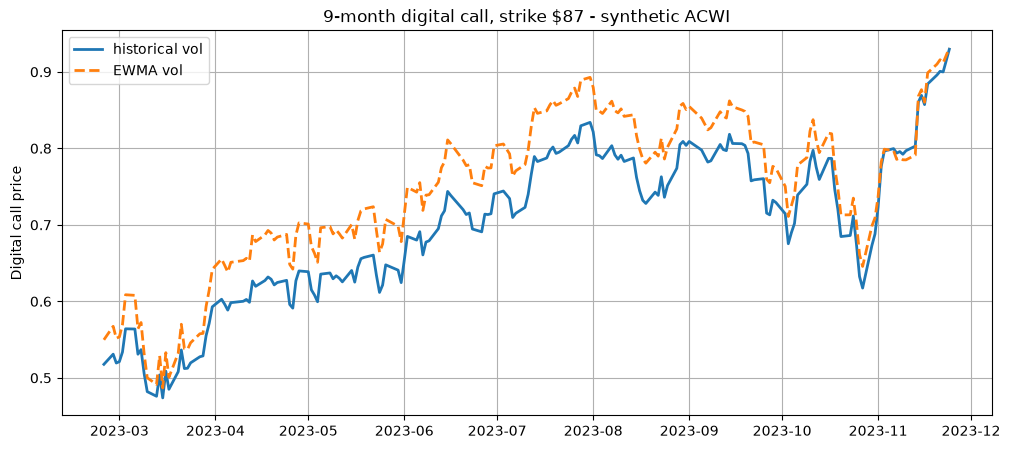

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(digital87_hist.index, digital87_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(digital87_ewma.index, digital87_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('9-month digital call, strike $87 - synthetic ACWI')
plt.ylabel('Digital call price')
plt.legend()
plt.grid(True)
plt.show()

## 12-month call spread, strikes \$78 and \$100

In [23]:
spread_hist = (price_series(call, 78, 1.0, vol_hist, expiry(1.0), units)
               - price_series(call, 100, 1.0, vol_hist, expiry(1.0), units))
spread_ewma = (price_series(call, 78, 1.0, vol_ewma, expiry(1.0), units)
               - price_series(call, 100, 1.0, vol_ewma, expiry(1.0), units))
deltaspread_hist = (price_series(call_delta, 78, 1.0, vol_hist, valuation_date, weights)
                    - price_series(call_delta, 100, 1.0, vol_hist, valuation_date, weights))

summary = pd.DataFrame({'price (hist vol)': spread_hist.iloc[0].round(2),
                        'price (EWMA vol)': spread_ewma.iloc[0].round(2),
                        'basket delta % (hist vol)': (deltaspread_hist.iloc[0] * 100).round(2)})
summary.loc['ACWI_synthetic', 'on-basket delta % (hedged)'] = \
    (call_delta(S_syn, K78s, 1.0, r_usd, q_syn, v_syn)
     - call_delta(S_syn, K100s, 1.0, r_usd, q_syn, v_syn)) * 100
print(f'As of {valuation_date}:')
summary.round(2).astype(object).fillna('')

As of 2023-02-24:

,price (hist vol),price (EWMA vol),basket delta % (hist vol),on-basket delta % (hedged)
IVV,47.47,49.62,41.05,
EWJ,6.9,7.12,48.5,
EWU,3.57,3.78,40.55,
MCHI,5.44,5.51,30.67,
EWG,3.08,3.21,36.76,
EWL,5.31,5.53,46.97,
ACWI_synthetic,10.43,10.87,40.96,43.73


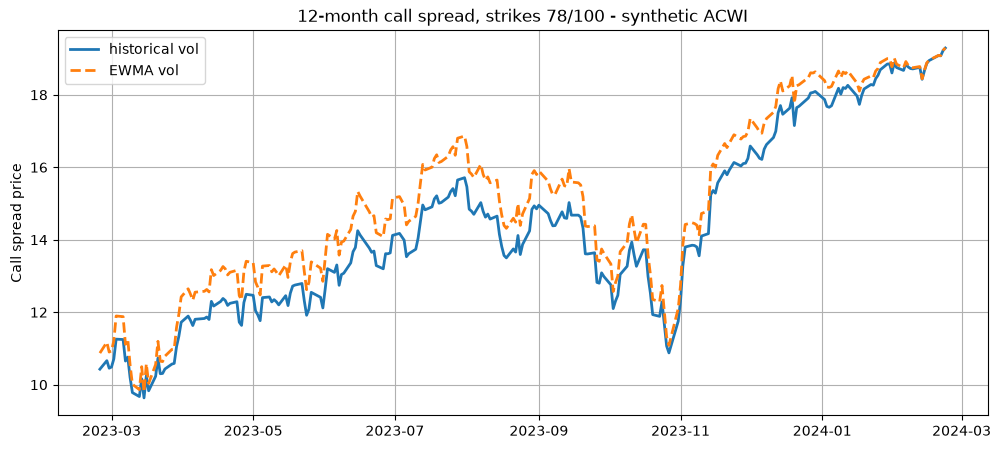

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(spread_hist.index, spread_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(spread_ewma.index, spread_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('12-month call spread, strikes $78/$100 - synthetic ACWI')
plt.ylabel('Call spread price')
plt.legend()
plt.grid(True)
plt.show()

## No-arbitrage guards

Every quote this notebook emits is asserted against its model-free bounds, per component and aggregated, on every mark-to-market day:

- vanilla call: $\max(Se^{-qT} - Ke^{-rT},\, 0) \le C \le Se^{-qT}$
- digital call: $0 \le D \le e^{-rT}$
- call spread: $0 \le C(K_1) - C(K_2) \le (K_2 - K_1)\,e^{-rT}$

The aggregate bounds are the same combination of the component bounds ($\sum_i n_i \,\cdot$ for proportional payoffs, $\sum_i w_i \,\cdot$ for the digital), so they apply exactly to the basket quote; put–call parity is asserted next to the pricing functions themselves. These checks cost nothing while they pass, the point is that a scaling or weighting mistake (quoting the basket in basket terms, mixing shares with dollar weights) blows through the upper bounds immediately, so the notebook refuses to emit an out-of-bounds quote instead of relying on the numbers happening to look reasonable.

In [25]:
def _S_T_grid(T_init, until):
    S = prices.loc[valuation_date:until, components]
    T = T_init - (S.index - S.index[0]).days / 365
    return S[T > 0].values, np.asarray(T[T > 0])[:, None]

def assert_bounds(quotes, lo, hi, agg, label):
    q_c, q_a = quotes[components].values, quotes['ACWI_synthetic'].values
    assert (q_c >= lo - 1e-9).all() and (q_c <= hi + 1e-9).all(), f'{label}: component bound violated'
    assert (q_a >= lo @ agg.values - 1e-9).all() and (q_a <= hi @ agg.values + 1e-9).all(), \
        f'{label}: aggregate bound violated'
    print(f'{label}: {q_a.size} daily marks within bounds')

for label, series in [('call $85 (hist vol)', call85_hist), ('call $85 (EWMA vol)', call85_ewma)]:
    S, T = _S_T_grid(0.75, expiry(0.75))
    hi = S * np.exp(-div[components].values * T)
    lo = np.maximum(hi - strikes.loc[components, 85].values * np.exp(-r_usd * T), 0)
    assert_bounds(series, lo, hi, units, label)

for label, series in [('digital $87 (hist vol)', digital87_hist), ('digital $87 (EWMA vol)', digital87_ewma)]:
    S, T = _S_T_grid(0.75, expiry(0.75))
    assert_bounds(series, np.zeros_like(S), np.exp(-r_usd * T) * np.ones_like(S), weights, label)

for label, series in [('spread $78/$100 (hist vol)', spread_hist), ('spread $78/$100 (EWMA vol)', spread_ewma)]:
    S, T = _S_T_grid(1.0, expiry(1.0))
    width = (strikes.loc[components, 100] - strikes.loc[components, 78]).values
    assert_bounds(series, np.zeros_like(S), width * np.exp(-r_usd * T), units, label)

call $85 (hist vol): 190 daily marks within bounds
call $85 (EWMA vol): 190 daily marks within bounds
digital $87 (hist vol): 190 daily marks within bounds
digital $87 (EWMA vol): 190 daily marks within bounds
spread $78/$100 (hist vol): 251 daily marks within bounds
spread $78/$100 (EWMA vol): 251 daily marks within bounds


## Basket of options vs option on the basket

A linear combination of options is not an option on the linear combination.

For the **call** the relationship is exact and pathwise, not merely an inequality in expectation. Because $K_i = S_i K / S_{ACWI}$ and $n_i = w_i S_{ACWI} / S_i$, the component strikes rebuild the quoted strike exactly, $\sum_i n_i K_i = K$, so on every path $\sum_i n_i (S_i - K_i)^+ \ge (\sum_i n_i S_i - K)^+$ by subadditivity of the positive part. The basket of calls **super-replicates** the call on the synthetic index state by state: whoever sells the ACWI call and buys the basket is over-hedged on every outcome, never just on average. The difference is the correlation premium, and no distributional assumption is needed to sign it.

For the **digital** there is no such relationship, and the table's small $-\$0.008$ understates how different the two products are. The basket pays $\sum_i w_i \mathbf{1}\{S_i > K_i\}$, a *fraction* of \$1 that lands strictly between 0 and 1 whenever the legs disagree; the digital that is actually sold, hedged and settled pays 0 or 1. The two agree in expectation and essentially never path by path, so what is quoted here is the price of one product against the payoff of another. The Monte Carlo section measures that residual: its mean is the $-\$0.008$ priced above, but its standard deviation is roughly twenty times larger, and that dispersion is carried uncompensated. The capped **spread** sits in between, non-convex above $K_2$ and likewise sign-flipped.

To quantify it, each option is priced directly on the synthetic index, with its own volatility and dividend yield, and the implied volatility is extracted from the basket quote.

In [26]:
print(f'Synthetic S = ${S_syn:.2f}, synthetic q = {q_syn:.2%}, historical vol = {v_syn:.2%}')

comparison = pd.DataFrame({
    'basket of options (quote)': [call85_hist.iloc[0]['ACWI_synthetic'],
                                  digital87_hist.iloc[0]['ACWI_synthetic'],
                                  spread_hist.iloc[0]['ACWI_synthetic']],
    'option on the basket': [call(S_syn, K85s, 0.75, r_usd, q_syn, v_syn),
                             digital(S_syn, K87s, 0.75, r_usd, q_syn, v_syn),
                             call(S_syn, K78s, 1.0, r_usd, q_syn, v_syn) - call(S_syn, K100s, 1.0, r_usd, q_syn, v_syn)],
}, index=['Call $85 (9m)', 'Digital call $87 (9m)', 'Call spread $78/$100 (12m)'])
comparison['correlation premium'] = comparison.iloc[:, 0] - comparison.iloc[:, 1]
comparison.round(3)

Synthetic S = $88.16, synthetic q = 2.00%, historical vol = 20.38%


,basket of options (quote),option on the basket,correlation premium
Call $85 (9m),9.258,8.765,0.493
Digital call $87 (9m),0.518,0.526,-0.008
Call spread $78/$100 (12m),10.428,10.560,-0.132


In [27]:
C_basket = call85_hist.iloc[0]['ACWI_synthetic']
implied_vol_syn = brentq(lambda s: call(S_syn, K85s, 0.75, r_usd, q_syn, s) - C_basket, 1e-4, 3.0)
print(f'Implied volatility of the synthetic call quote: {implied_vol_syn:.2%}')
print(f'Historical volatility of the synthetic index:   {v_syn:.2%}')

Implied volatility of the synthetic call quote: 22.17%
Historical volatility of the synthetic index:   20.38%


## Skew sensitivity: where flat vol actually bites

The digital and the spread live next to their strikes, exactly where the flat-vol assumption is weakest. On a real surface a cash-or-nothing digital is the tight-call-spread limit $-\partial C/\partial K$ taken *along the skew*, which adds $-\text{Vega} \cdot \partial\sigma/\partial K$ to the flat-vol $e^{-rT}N(d_2)$; with the negative skew typical of equity indices that correction is positive, so flat vol systematically under-quotes a digital, the reason desks replicate digitals as tight call spreads on the surface instead of pricing the formula. The \$78/\$100 spread straddles two strikes and picks up the skew *difference* between them. The vanilla call is convex and near the money, so it barely reacts.

There is no listed ACWI surface to calibrate to, that absence is the premise of the whole exercise, so the headline quotes stay flat-vol and the exposure is quantified instead: every leg is repriced under a linear skew in log-moneyness, $\sigma_i(K) = \sigma_i + s \cdot \ln(K/S_{ACWI})/10\%$, sweeping the slope $s$ over the range typical of equity indices (0 to −3 vol points per 10% of moneyness; all legs share the ACWI option's moneyness by construction, so the same shift applies across legs). The digital is repriced the way a desk would trade it: a call spread ±1% around the strike, each leg on its skewed vol.

In [28]:
def basket_call_skew(K, T, slope):
    """Basket-of-calls quote with each leg on a skewed vol; slope in vol pts per 10% log-moneyness."""
    sig = vol_hist[components].values + slope / 100 * np.log(K / S_A) / 0.10
    return (units.values * call(S0.values, S0.values * K / S_A, T, r_usd, div[components].values, sig)).sum()

h = 0.87   # the ±1% call-spread replication of the $1 digital payoff
slopes = [0, -1, -2, -3]
skew_table = pd.DataFrame({
    'call $85 (9m)': {s: basket_call_skew(85, 0.75, s) for s in slopes},
    'digital $87 (9m)': {s: (basket_call_skew(87 - h, 0.75, s) - basket_call_skew(87 + h, 0.75, s)) / (2 * h)
                         for s in slopes},
    'call spread $78/$100 (12m)': {s: basket_call_skew(78, 1.0, s) - basket_call_skew(100, 1.0, s) for s in slopes}})
skew_table.index.name = 'skew slope (vol pts per 10% moneyness)'
pd.concat([skew_table.round(3), (skew_table / skew_table.iloc[0] - 1).map('{:+.1%}'.format)],
          axis=1, keys=['price', 'vs flat vol'])

price                   \
                                       call $85 (9m) digital $87 (9m)   
skew slope (vol pts per 10% moneyness)                                  
 0                                             9.258            0.518   
-1                                             9.358            0.550   
-2                                             9.459            0.583   
-3                                             9.560            0.615   

                                                                   \
                                       call spread $78/$100 (12m)   
skew slope (vol pts per 10% moneyness)                              
 0                                                         10.428   
-1                                                         11.145   
-2                                                         11.863   
-3                                                         12.582   

                                         vs flat vol                   \
                                       call $85 (9m) digital $87 (9m)   
skew slope (vol pts per 10% moneyness)                                  
 0                                             +0.0%            +0.0%   
-1                                             +1.1%            +6.3%   
-2                                             +2.2%           +12.5%   
-3                                             +3.3%           +18.8%   

                                                                   
                                       call spread $78/$100 (12m)  
skew slope (vol pts per 10% moneyness)                             
 0                                                          +0.0%  
-1                                                          +6.9%  
-2                                                         +13.8%  
-3                                                         +20.7%

At the steep end of the sweep the call moves 3.3%, the flat-vol \$9.26 headline is robust. The digital gains up to 18.8% (\$0.518 → \$0.615) and the spread up to 20.7% (\$10.43 → \$12.58): under a realistic negative skew both are **under-quoted** by flat vol, so part of their negative hedging P&L in the backtest below is a flat-vol artifact rather than pure concentrated gamma, sold at a skew-consistent price they would have carried an extra 6–20% of premium as cushion. (At slope 0 the ±1% call-spread replication reproduces the closed-form digital quote of \$0.518, confirming the two views are consistent.)

## Delta-hedging backtest

Validation of the quotes: each option is **sold at the basket-of-options premium** (historical vol) and delta-hedged daily **with the synthetic index treated as a single asset at its own vol `v_syn`**, the `on-basket Δ` of the pricing tables. That asymmetry is deliberate, it is what a desk quoting a basket and hedging a tracker actually does, and it is the source of the correlation P&L the Monte Carlo below decomposes. Cash accrues at the USD rate and the position in the underlying earns its dividend yield. Products with concentrated gamma (the digital near the strike) show a larger hedging error, which is why in practice they are quoted with an extra margin or replicated with a call spread.

In [29]:
def hedge_backtest(premium, delta_fn, payoff, T_init, until):
    """Sold at `premium` (the basket quote), hedged with delta_fn, the option-on-the-basket delta."""
    S = prices.loc[valuation_date:until, 'ACWI_synthetic']
    T = np.maximum(T_init - (S.index - S.index[0]).days / 365, 1e-9)
    delta = delta_fn(S.values, T)
    cash = premium - delta[0] * S.iloc[0]
    for i in range(1, len(S)):
        dt = T[i - 1] - T[i]
        cash = cash * np.exp(r_usd * dt) + delta[i - 1] * S.iloc[i - 1] * q_syn * dt
        cash -= (delta[i] - delta[i - 1]) * S.iloc[i]
    pnl = delta[-1] * S.iloc[-1] + cash - payoff(S.iloc[-1])
    return {'premium received': premium, 'final S': S.iloc[-1], 'payoff paid': payoff(S.iloc[-1]),
            'hedging P&L': pnl, 'P&L % of premium': pnl / premium * 100}

results = pd.DataFrame({
    'Call $85 (9m)': hedge_backtest(
        call85_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: call_delta(s, K85s, t, r_usd, q_syn, v_syn),
        lambda s: max(s - K85s, 0), 0.75, expiry(0.75)),
    'Digital call $87 (9m)': hedge_backtest(
        digital87_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: digital_delta(s, K87s, t, r_usd, q_syn, v_syn),
        lambda s: float(s > K87s), 0.75, expiry(0.75)),
    'Call spread $78/$100 (12m)': hedge_backtest(
        spread_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: call_delta(s, K78s, t, r_usd, q_syn, v_syn) - call_delta(s, K100s, t, r_usd, q_syn, v_syn),
        lambda s: np.clip(s - K78s, 0, K100s - K78s), 1.0, expiry(1.0)),
}).T
results.round(3)

,premium received,final S,payoff paid,hedging P&L,P&L % of premium
Call $85 (9m),9.258,97.393,12.393,2.187,23.627
Digital call $87 (9m),0.518,97.393,1.000,-0.214,-41.332
Call spread $78/$100 (12m),10.428,106.036,22.000,-3.575,-34.281


## Monte Carlo: multivariate hedging error, and what the correlation premium actually is

The backtest above is one realized path, and a single-asset simulation of the synthetic index could not test the thesis of this notebook: with one GBM the only thing a hedging simulation can produce is rebalancing error, so it validates the machinery, never the aggregation. Here the six legs are simulated **jointly** as correlated GBMs, with the correlation matrix estimated on the same pre-valuation window as the vols, and each product is sold at its basket-of-options quote and delta-hedged with the on-basket delta, exactly as in the backtest. The generator is seeded, so the numbers are identical on every run.

Two scenarios per product:

- **realized σ = quoted σ, historical correlation:** every leg realizes exactly the vol it was priced at, so the mean P&L isolates what the aggregation itself earns or costs. The cell after the histogram is precise about what that mean does and does not prove;
- **realized σ = EWMA, historical correlation:** the margin embedded in quoting at historical vol if the recent, lower-vol regime persists, the scenario closest to what the hedging window actually delivered, so its 5th–95th band is the fair error bar on the single-path backtest numbers above.

In [30]:
corr_hist = prior_returns[components].corr().values

def simulate_basket(T0, vols, n_sims=5000, seed=42):
    """Correlated GBM paths for the six legs, aggregated into the synthetic basket with the same
    fixed share counts n_i that are quoted and hedged. Returns the basket paths and the step."""
    rng = np.random.default_rng(seed)
    m = round(T0 * 252)
    dt = T0 / m
    cov = corr_hist * np.outer(vols[components], vols[components])
    steps = (r_usd - div[components].values - np.diag(cov) / 2) * dt \
            + rng.standard_normal((m, n_sims, len(components))) @ np.linalg.cholesky(cov).T * np.sqrt(dt)
    legs = S0.values * np.exp(np.concatenate([np.zeros((1, n_sims, len(components))), np.cumsum(steps, axis=0)]))
    return legs @ units.values, dt, legs

def mc_hedge_basket(quote, delta_fn, payoff, T0, vols, n_sims=5000, seed=42):
    """Sell at the basket-of-options quote and delta-hedge the synthetic index daily, with the
    on-basket delta, exactly as in the realized backtest."""
    S, dt, _ = simulate_basket(T0, vols, n_sims, seed)
    m = S.shape[0] - 1
    T = T0 - np.arange(m)[:, None] * dt
    delta = delta_fn(S[:-1], T)
    cash = quote - delta[0] * S[0]
    for i in range(1, m):
        cash = cash * np.exp(r_usd * dt) + delta[i - 1] * S[i - 1] * q_syn * dt
        cash -= (delta[i] - delta[i - 1]) * S[i]
    cash = cash * np.exp(r_usd * dt) + delta[-1] * S[-2] * q_syn * dt
    pnl = delta[-1] * S[-1] + cash - payoff(S[-1])
    return pnl / quote * 100

products = {
    'call $85 (9m)': (call85_hist.iloc[0]['ACWI_synthetic'],
                      lambda s, t: call_delta(s, K85s, t, r_usd, q_syn, v_syn),
                      lambda s: np.maximum(s - K85s, 0), 0.75),
    'digital $87 (9m)': (digital87_hist.iloc[0]['ACWI_synthetic'],
                         lambda s, t: digital_delta(s, K87s, t, r_usd, q_syn, v_syn),
                         lambda s: (s > K87s).astype(float), 0.75),
    'spread $78/$100 (12m)': (spread_hist.iloc[0]['ACWI_synthetic'],
                              lambda s, t: call_delta(s, K78s, t, r_usd, q_syn, v_syn)
                                           - call_delta(s, K100s, t, r_usd, q_syn, v_syn),
                              lambda s: np.clip(s - K78s, 0, K100s - K78s), 1.0),
}
mc = pd.DataFrame({(name, scen): mc_hedge_basket(quote, delta_fn, payoff, T0, vols)
                   for name, (quote, delta_fn, payoff, T0) in products.items()
                   for scen, vols in [('realized σ = quoted', vol_hist), ('realized σ = EWMA', vol_ewma)]})
mc.describe(percentiles=[0.05, 0.5, 0.95]).round(2)

call $85 (9m)                      digital $87 (9m)  \
      realized σ = quoted realized σ = EWMA realized σ = quoted   
count             5000.00           5000.00             5000.00   
mean                 5.63             20.55               -1.42   
std                  3.98              6.22               21.30   
min                -16.96              6.75             -196.32   
5%                  -0.74             11.18              -24.90   
50%                  5.58             20.09               -1.60   
95%                 12.22             31.53               23.16   
max                 23.38             42.69              148.53   

                        spread $78/$100 (12m)                    
      realized σ = EWMA   realized σ = quoted realized σ = EWMA  
count           5000.00               5000.00           5000.00  
mean              -7.84                 -1.29             -6.04  
std               28.52                  3.87             12.29  
min             -165.74                -19.92            -38.48  
5%               -51.52                 -7.66            -24.57  
50%              -11.76                 -1.21             -7.37  
95%               37.18                  4.82             13.24  
max              159.41                 20.04             24.60

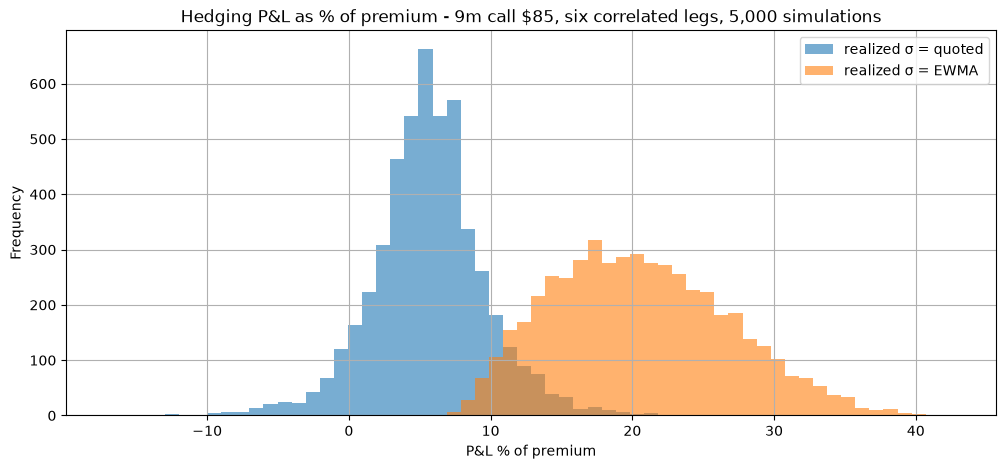

In [31]:
mc['call $85 (9m)'].plot.hist(bins=60, alpha=0.6, figsize=(12, 5),
    title='Hedging P&L as % of premium - 9m call $85, six correlated legs, 5,000 simulations')
plt.xlabel('P&L % of premium')
plt.grid(True)
plt.show()

In [32]:
premium_check = pd.DataFrame({
    name: {'mean MC P&L, hedged at v_syn ($)': mc[(name, 'realized σ = quoted')].mean() / 100 * quote,
           'MC standard error ($)': mc[(name, 'realized σ = quoted')].sem() / 100 * quote,
           'quote - option-on-basket ($)': comparison['correlation premium'].iloc[j]}
    for j, (name, (quote, *_)) in enumerate(products.items())}).T
print(premium_check.round(4), '\n')

# The two columns differ by ~3 cents on the call, and the reason is worth pinning down rather than
# writing off as approximation error. v_syn = std(sum w_i r_i) = sqrt(w' Sigma w) is the volatility
# of a *constant-weight* basket, one rebalanced back to w every day. What is quoted, hedged and
# delivered is a *fixed-share* basket: the weights drift as the legs move, and over the option's
# life that basket realizes about 10bp less vol. Price the option on the basket at the vol the
# simulated basket actually realizes and the gap closes. This reuses seed=42 -- the *same* paths the
# MC hedge consumed -- so it decomposes one sample rather than confirming it independently: the two
# figures agree far more tightly than the +/-$0.005 standard error above would support on its own.
call_quote = call85_hist.iloc[0]['ACWI_synthetic']
S_paths, dt_mc, _ = simulate_basket(0.75, vol_hist)
v_realized = (np.log(S_paths[1:] / S_paths[:-1]).std(axis=0) / np.sqrt(dt_mc)).mean()
reconcile = pd.DataFrame({
    'vol used': [v_syn, v_realized, np.nan],
    'option on the basket': [call(S_syn, K85s, 0.75, r_usd, q_syn, v_syn),
                             call(S_syn, K85s, 0.75, r_usd, q_syn, v_realized), np.nan],
    'premium': [call_quote - call(S_syn, K85s, 0.75, r_usd, q_syn, v_syn),
                call_quote - call(S_syn, K85s, 0.75, r_usd, q_syn, v_realized),
                mc[('call $85 (9m)', 'realized σ = quoted')].mean() / 100 * call_quote]},
    index=['v_syn: constant-weight basket', 'what the fixed-share basket realizes',
           'measured by the MC hedge'])
print('9m call, reconciling the two views:')
print(reconcile.round(4).to_string(na_rep='-'), '\n')

# The digital's -$0.008 is a *mean*, and for that product the mean hides most of the story. The
# basket pays sum w_i*1{S_i > K_i}, a fraction of $1; the digital sold, hedged and settled pays 0 or
# 1. They agree in expectation and essentially never per path, so the basket is not a replication of
# the digital at all -- unlike the call, where sum n_i*K_i = K makes the basket dominate it pathwise.
legs_T = simulate_basket(0.75, vol_hist)[2][-1]
basket_pay = (legs_T > strikes.loc[components, 87].values) @ weights.values
resid = basket_pay - (legs_T @ units.values > K87s)
print(f'digital, basket payoff vs delivered payoff: mean {resid.mean():+.4f} (what the quote prices), '
      f'std {resid.std():.4f}, partial payoff on {((basket_pay > 0.01) & (basket_pay < 0.99)).mean():.0%} '
      f'of paths\n')

# What is *not* an identity is where the premium comes from. Under the risk-neutral measure a
# self-financing delta strategy has zero expected P&L whatever delta it uses, so the mean is
# quote - E_Q[payoff] however the hedge is run; only the dispersion depends on the hedging vol,
# and it is minimized near the vol the basket actually realizes.
# Call only: the digital and the spread would each need their own implied-vol root-find, and the
# spread's vega changes sign between its strikes, so brentq is not safe there unbracketed.
hedge_vols = {f'{v_syn - 0.10:.1%}': v_syn - 0.10,
              f'{v_syn - 0.05:.1%}': v_syn - 0.05,
              f'{v_syn:.1%} (v_syn, hedged above)': v_syn,
              f'{implied_vol_syn:.1%} (the quote implied)': implied_vol_syn,
              f'{implied_vol_syn + 0.05:.1%}': implied_vol_syn + 0.05}
sweep = pd.DataFrame({
    label: mc_hedge_basket(call_quote,
                           lambda x, t, sg=sigma: call_delta(x, K85s, t, r_usd, q_syn, sg),
                           lambda x: np.maximum(x - K85s, 0), 0.75, vol_hist) / 100 * call_quote
    for label, sigma in hedge_vols.items()})

print('9m call sold at the basket quote, delta-hedged at different vols (realized σ = quoted σ):')
pd.DataFrame({'mean P&L ($)': sweep.mean(), 'std ($)': sweep.std(),
              '5th pct ($)': sweep.quantile(0.05), '95th pct ($)': sweep.quantile(0.95)}).round(3)

                       mean MC P&L, hedged at v_syn ($)  \
call $85 (9m)                                    0.5208   
digital $87 (9m)                                -0.0074   
spread $78/$100 (12m)                           -0.1342   

                       MC standard error ($)  quote - option-on-basket ($)  
call $85 (9m)                         0.0052                        0.4930  
digital $87 (9m)                      0.0016                       -0.0083  
spread $78/$100 (12m)                 0.0057                       -0.1323   



9m call, reconciling the two views:
                                      vol used  option on the basket  premium
v_syn: constant-weight basket           0.2038                8.7647   0.4930
what the fixed-share basket realizes    0.2028                8.7376   0.5201
measured by the MC hedge                     -                     -   0.5208 

digital, basket payoff vs delivered payoff: mean -0.0085 (what the quote prices), std 0.1984, partial payoff on 54% of paths



9m call sold at the basket quote, delta-hedged at different vols (realized σ = quoted σ):


,mean P&L ($),std ($),5th pct ($),95th pct ($)
10.4%,0.533,1.554,-2.228,2.728
15.4%,0.528,0.740,-0.815,1.544
"20.4% (v_syn, hedged above)",0.521,0.368,-0.068,1.131
22.2% (the quote implied),0.518,0.421,-0.056,1.290
27.2%,0.510,0.760,-0.642,1.865


### What the two columns do and do not show

The mean hedging P&L at the quoted vols matches the correlation premium of the pricing section for all three products. This is a strong consistency check, but "two independent computations of the premium" would overstate it, and the residual gap has a specific cause worth naming. The standard errors are printed alongside: on the digital and the spread the two columns sit well inside one standard error of each other, so those two "matches" are consistent rather than precise, while the call's three-cent gap is about five standard errors wide and genuinely needed explaining.

Under the risk-neutral measure a self-financing delta strategy has zero expected P&L *whatever delta it uses*, so the left column is exactly `quote − E_Q[payoff on the simulated basket]`. The right column is `quote − P_BS(v_syn)`, the same thing with the expectation replaced by a Black–Scholes value. The two therefore have to agree up to whatever `P_BS(v_syn)` gets wrong about the basket, and on the call that is about three cents.

The reconciliation above identifies it, and it is not the basket-of-lognormals approximation. `v_syn` is `std(Σ wᵢrᵢ) = √(w′Σw)`, the volatility of a **constant-weight** basket, one rebalanced back to `w` every day. What is quoted, hedged and delivered is a **fixed-share** basket: the weights drift as the legs move, and over the option's life it realizes about 10bp less volatility. Repricing the option on the basket at the vol the simulated basket actually realizes closes the gap. That reconciliation reuses `seed=42`, i.e. the *same* simulated paths the hedge consumed, so it decomposes one sample rather than confirming it independently, and the two figures land closer than the \$0.005 Monte Carlo standard error printed above would support on its own. What survives is the identification of the cause, not the last decimal of the match: the residual after it is the genuine lognormal-approximation and discrete-rebalancing error, and it is small.

None of this establishes that the premium exists: for a convex payoff that is Jensen's inequality, a theorem, and no simulation is needed to confirm it. What the agreement does establish is that the pricing code, the aggregation and the simulation all describe the same instrument, to a known and explainable tolerance.

The hedge-vol sweep carries the part that is not mechanical. The mean P&L is flat at ≈ +\$0.52 across hedging vols from 10.4% to 27.2%, exactly as the zero-expected-P&L argument requires, so the premium is not an artifact of hedging at one particular vol. What the hedging vol does control is dispersion: the standard deviation is minimized near `v_syn` (\$0.37) and blows out to \$1.55 at 10.4%. Hedging at the vol the basket actually realizes does not earn the premium, it earns it *reliably*. The premium itself is payment for carrying the aggregation risk between a basket of options and an option on the basket.

### Error bars on the backtest

The EWMA scenario puts a distribution around the single realized path. The call's +23.6% sits near the middle of its band (mean +20.6%, 5th–95th +11.2% to +31.5%). The digital's −41.3% is inside its very wide band (−51.5% to +37.2%), concentrated gamma as advertised, now with a distribution around it instead of a single anecdote.

The spread's −34.3% falls *below* its 5th percentile (−24.6%), and two things contribute. The window was a nearly one-way rally through the short strike, the kind of trending path a GBM with independent increments underweights; and the skew sweep above shows the flat-vol quote understates the spread by up to 20.7%, so a desk quoting on a real surface would have collected a materially larger premium against the same hedging losses. The band is built from the model's own assumptions, not just its parameters, and a result outside it is a statement about the model as much as about the path.